In [1]:
# ===== CELL 1 — Imports, seed, device, config =====
import time, random, numpy as np, torch, torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

QUICK_TEST = False           # True -> 2 epochs for a quick smoke test
EPOCHS = 2 if QUICK_TEST else 30
BATCH_SIZE = 128
CIFAR_CLASSES = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']

Device: cuda


In [2]:
# ===== CELL 2 — CIFAR-10 data: 45k/5k/10k split + loaders =====
MEAN, STD = (0.4914,0.4822,0.4465), (0.2470,0.2435,0.2616)
train_tf = T.Compose([T.RandomCrop(32,padding=4), T.RandomHorizontalFlip(), T.ToTensor(), T.Normalize(MEAN,STD)])
eval_tf  = T.Compose([T.ToTensor(), T.Normalize(MEAN,STD)])

full_aug   = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=train_tf)
full_clean = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=eval_tf)
test_set   = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=eval_tf)

g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(len(full_aug), generator=g).tolist()
train_set = Subset(full_aug, perm[:45000])
val_set   = Subset(full_clean, perm[45000:])

train_loader = DataLoader(train_set, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   256,        shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  256,        shuffle=False, num_workers=2, pin_memory=True)
print(f"train={len(train_set)} val={len(val_set)} test={len(test_set)}")

100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


train=45000 val=5000 test=10000


In [3]:
# ===== CELL 3 — Utilities: param count, train, eval, plots, filters =====
def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval(); correct=total=0; loss_sum=0.0
    for x,y in loader:
        x,y=x.to(device),y.to(device); out=model(x)
        if criterion is not None: loss_sum+=criterion(out,y).item()*x.size(0)
        correct+=(out.argmax(1)==y).sum().item(); total+=x.size(0)
    return correct/total, (loss_sum/total if criterion is not None else None)

def train_model(model, label, epochs=EPOCHS, lr=0.01, weight_decay=5e-4):
    set_seed(); model=model.to(device)
    crit=nn.CrossEntropyLoss()
    opt=torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay, nesterov=True)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    h={'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[],'epoch_time':[],'label':label,'params':count_params(model)}
    print(f"\n=== {label} | params={h['params']:,} | epochs={epochs} | lr={lr} ===")
    for ep in range(epochs):
        model.train(); t0=time.time(); rl=rc=rt=0
        for x,y in train_loader:
            x,y=x.to(device),y.to(device); opt.zero_grad()
            out=model(x); loss=crit(out,y); loss.backward(); opt.step()
            rl+=loss.item()*x.size(0); rc+=(out.argmax(1)==y).sum().item(); rt+=x.size(0)
        sch.step(); dt=time.time()-t0
        tr_loss,tr_acc=rl/rt, rc/rt
        va,vl=evaluate(model,val_loader,crit)
        h['train_loss'].append(tr_loss); h['val_loss'].append(vl)
        h['train_acc'].append(tr_acc);   h['val_acc'].append(va); h['epoch_time'].append(dt)
        print(f"  ep {ep+1:02d}/{epochs} train_loss={tr_loss:.3f} acc={tr_acc:.3f} | val_loss={vl:.3f} acc={va:.3f} | {dt:.1f}s")
    h['avg_epoch_time']=float(np.mean(h['epoch_time'])); return model,h

def plot_history(hs, title="Training curves"):
    fig,ax=plt.subplots(1,2,figsize=(13,4.5))
    for h in hs:
        ep=range(1,len(h['train_loss'])+1)
        ax[0].plot(ep,h['train_loss'],'--',label=f"{h['label']} train")
        ax[0].plot(ep,h['val_loss'],'-',label=f"{h['label']} val")
        ax[1].plot(ep,h['val_acc'],'-',label=f"{h['label']} val acc")
    ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss'); ax[0].set_title(f'{title}: loss'); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Accuracy'); ax[1].set_title(f'{title}: val acc'); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

def plot_confusion(model, label=""):
    model.eval(); ys=[]; ps=[]
    with torch.no_grad():
        for x,y in test_loader:
            ps.append(model(x.to(device)).argmax(1).cpu()); ys.append(y)
    cm=confusion_matrix(torch.cat(ys).numpy(), torch.cat(ps).numpy())
    fig,axc=plt.subplots(figsize=(7,6))
    ConfusionMatrixDisplay(cm,display_labels=CIFAR_CLASSES).plot(ax=axc,xticks_rotation=45,colorbar=False)
    axc.set_title(f'Confusion matrix — {label}'); plt.tight_layout(); plt.show(); return cm

def show_first_conv_filters(model, label=""):
    fc=None
    for m in model.modules():
        if isinstance(m,nn.Conv2d): fc=m; break
    if fc is None or fc.in_channels!=3: print("No 3-ch first conv."); return
    w=fc.weight.detach().cpu(); w=(w-w.min())/(w.max()-w.min()+1e-8)
    grid=torchvision.utils.make_grid(w[:min(64,w.size(0))],nrow=8,padding=1)
    plt.figure(figsize=(6,6)); plt.imshow(grid.permute(1,2,0)); plt.axis('off')
    plt.title(f'First conv filters — {label}'); plt.show()

def report_test(model,label):
    acc,_=evaluate(model,test_loader); print(f"{label}: TEST accuracy = {acc*100:.2f}%"); return acc

In [4]:
# ===== CELL 4 — Adapted VGG + pick config closest to AlexNet param count =====
VGG_CFG = {
 'VGG11':[64,'M',128,'M',256,256,'M',512,512,'M',512,512,'M'],
 'VGG13':[64,64,'M',128,128,'M',256,256,'M',512,512,'M',512,512,'M'],
 'VGG16':[64,64,'M',128,128,'M',256,256,256,'M',512,512,512,'M',512,512,512,'M'],
 'VGG19':[64,64,'M',128,128,'M',256,256,256,256,'M',512,512,512,512,'M',512,512,512,512,'M'],
}
class ModifiedVGG(nn.Module):
    def __init__(self, cfg='VGG11', num_classes=10, dropout=0.0, use_bn=False):
        super().__init__(); layers=[]; c=3
        for v in VGG_CFG[cfg]:
            if v=='M': layers.append(nn.MaxPool2d(2))
            else:
                layers.append(nn.Conv2d(c,v,3,padding=1))
                if use_bn: layers.append(nn.BatchNorm2d(v))
                layers.append(nn.ReLU(inplace=True)); c=v
        self.features=nn.Sequential(*layers)              # 32->1, 512 channels
        self.classifier=nn.Sequential(nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(512,512), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(512,num_classes))
    def forward(self,x): return self.classifier(self.features(x))

class ModifiedAlexNet(nn.Module):   # same as Problem 1, used only for the param target
    def __init__(self, num_classes=10, dropout=0.0):
        super().__init__()
        def conv(i,o): return [nn.Conv2d(i,o,3,padding=1), nn.ReLU(inplace=True)]
        self.features=nn.Sequential(*conv(3,64),nn.MaxPool2d(2),*conv(64,192),nn.MaxPool2d(2),
            *conv(192,384),*conv(384,256),*conv(256,256),nn.MaxPool2d(2))
        self.classifier=nn.Sequential(nn.Flatten(),nn.Dropout(dropout),nn.Linear(256*4*4,1024),
            nn.ReLU(inplace=True),nn.Dropout(dropout),nn.Linear(1024,512),nn.ReLU(inplace=True),nn.Linear(512,num_classes))
    def forward(self,x): return self.classifier(self.features(x))

target = count_params(ModifiedAlexNet()); print(f"Target (Modified AlexNet) params: {target:,}\n")
for name in VGG_CFG:
    p=count_params(ModifiedVGG(name)); print(f"  {name}: {p:,}  (|diff|={abs(p-target):,})")
chosen = min(VGG_CFG, key=lambda n: abs(count_params(ModifiedVGG(n))-target))
print(f"\n--> Chosen VGG (closest param count): {chosen}")

Target (Modified AlexNet) params: 6,976,842

  VGG11: 9,488,266  (|diff|=2,511,424)
  VGG13: 9,672,778  (|diff|=2,695,936)
  VGG16: 14,982,474  (|diff|=8,005,632)
  VGG19: 20,292,170  (|diff|=13,315,328)

--> Chosen VGG (closest param count): VGG11



=== VGG11 (no dropout) | params=9,488,266 | epochs=30 | lr=0.01 ===
  ep 01/30 train_loss=2.303 acc=0.099 | val_loss=2.303 acc=0.106 | 17.6s
  ep 02/30 train_loss=2.303 acc=0.098 | val_loss=2.303 acc=0.106 | 17.2s
  ep 03/30 train_loss=2.303 acc=0.101 | val_loss=2.303 acc=0.100 | 18.5s
  ep 04/30 train_loss=2.303 acc=0.099 | val_loss=2.303 acc=0.103 | 17.5s
  ep 05/30 train_loss=2.303 acc=0.103 | val_loss=2.302 acc=0.100 | 17.2s
  ep 06/30 train_loss=2.302 acc=0.105 | val_loss=2.302 acc=0.148 | 16.9s
  ep 07/30 train_loss=2.250 acc=0.153 | val_loss=2.025 acc=0.212 | 17.6s
  ep 08/30 train_loss=1.892 acc=0.251 | val_loss=1.759 acc=0.316 | 17.3s
  ep 09/30 train_loss=1.723 acc=0.322 | val_loss=1.677 acc=0.349 | 18.2s
  ep 10/30 train_loss=1.592 acc=0.380 | val_loss=1.446 acc=0.445 | 17.1s
  ep 11/30 train_loss=1.435 acc=0.450 | val_loss=1.435 acc=0.469 | 18.4s
  ep 12/30 train_loss=1.256 acc=0.530 | val_loss=1.159 acc=0.570 | 17.3s
  ep 13/30 train_loss=1.103 acc=0.595 | val_loss=0.998 

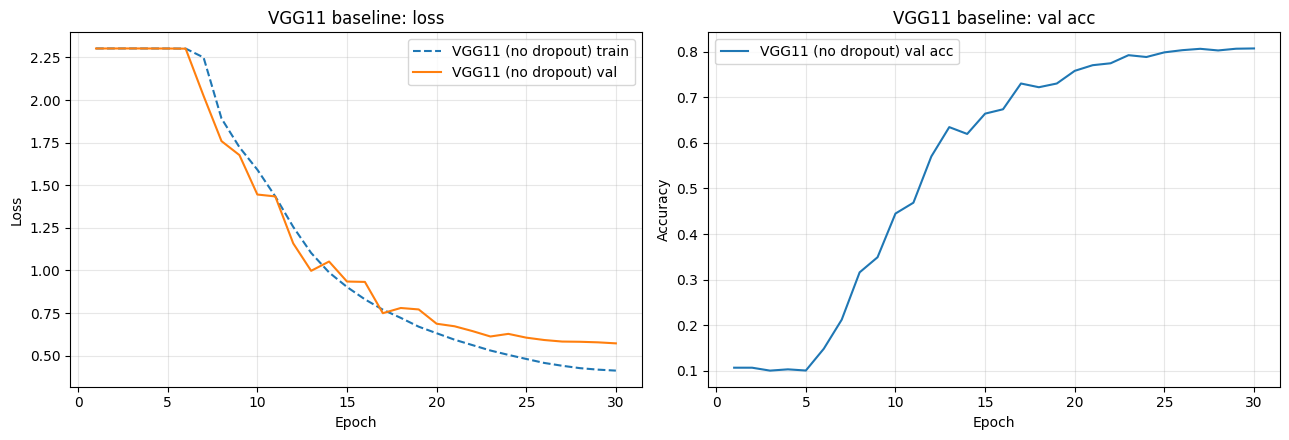

VGG11 baseline: TEST accuracy = 80.85%


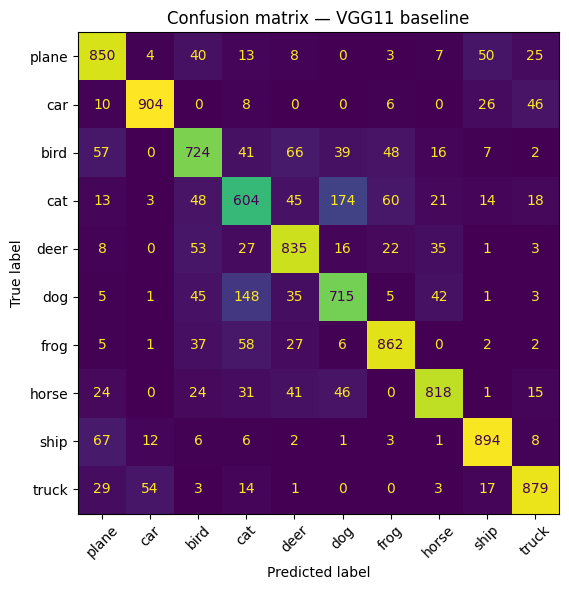

array([[850,   4,  40,  13,   8,   0,   3,   7,  50,  25],
       [ 10, 904,   0,   8,   0,   0,   6,   0,  26,  46],
       [ 57,   0, 724,  41,  66,  39,  48,  16,   7,   2],
       [ 13,   3,  48, 604,  45, 174,  60,  21,  14,  18],
       [  8,   0,  53,  27, 835,  16,  22,  35,   1,   3],
       [  5,   1,  45, 148,  35, 715,   5,  42,   1,   3],
       [  5,   1,  37,  58,  27,   6, 862,   0,   2,   2],
       [ 24,   0,  24,  31,  41,  46,   0, 818,   1,  15],
       [ 67,  12,   6,   6,   2,   1,   3,   1, 894,   8],
       [ 29,  54,   3,  14,   1,   0,   0,   3,  17, 879]])

In [5]:
# ===== CELL 5 — Part A: train chosen VGG =====
vgg, h_vgg = train_model(ModifiedVGG(chosen, dropout=0.0), f"{chosen} (no dropout)", lr=0.01)
plot_history([h_vgg], f"{chosen} baseline")
acc_vgg = report_test(vgg, f"{chosen} baseline")
plot_confusion(vgg, f"{chosen} baseline")


=== VGG11 drop=0.3 | params=9,488,266 | epochs=30 | lr=0.01 ===
  ep 01/30 train_loss=2.303 acc=0.099 | val_loss=2.303 acc=0.106 | 18.0s
  ep 02/30 train_loss=2.303 acc=0.098 | val_loss=2.303 acc=0.106 | 17.7s
  ep 03/30 train_loss=2.303 acc=0.100 | val_loss=2.303 acc=0.100 | 18.1s
  ep 04/30 train_loss=2.302 acc=0.106 | val_loss=2.301 acc=0.143 | 17.8s
  ep 05/30 train_loss=2.191 acc=0.161 | val_loss=1.989 acc=0.196 | 18.3s
  ep 06/30 train_loss=1.924 acc=0.215 | val_loss=1.835 acc=0.262 | 17.7s
  ep 07/30 train_loss=1.802 acc=0.282 | val_loss=1.675 acc=0.345 | 18.2s
  ep 08/30 train_loss=1.651 acc=0.352 | val_loss=1.522 acc=0.418 | 17.6s
  ep 09/30 train_loss=1.514 acc=0.413 | val_loss=1.424 acc=0.466 | 17.8s
  ep 10/30 train_loss=1.392 acc=0.470 | val_loss=1.263 acc=0.526 | 17.5s
  ep 11/30 train_loss=1.223 acc=0.549 | val_loss=1.258 acc=0.554 | 17.9s
  ep 12/30 train_loss=1.082 acc=0.608 | val_loss=1.008 acc=0.642 | 17.5s
  ep 13/30 train_loss=0.980 acc=0.647 | val_loss=0.964 acc=

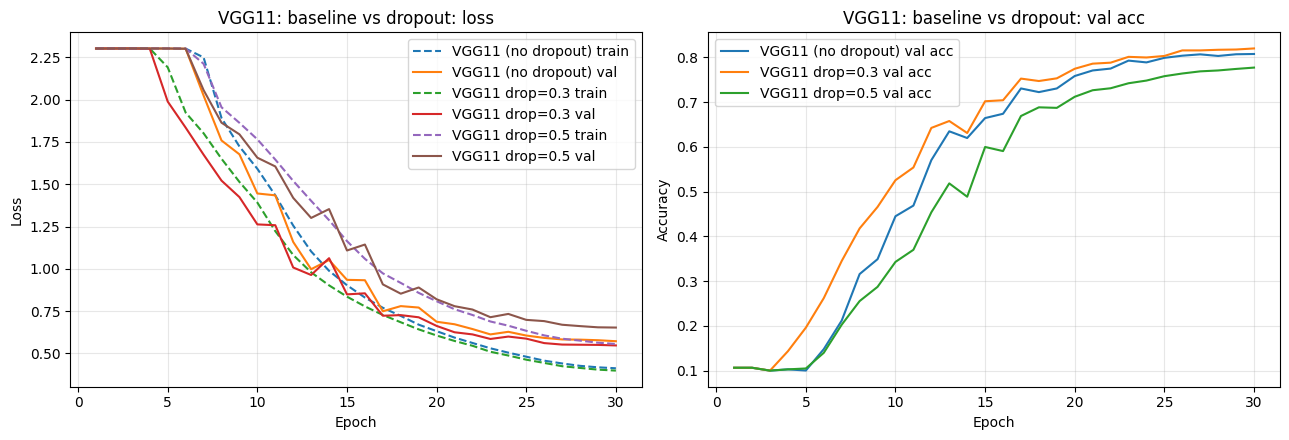

VGG11 drop=0.3: TEST accuracy = 81.73%
VGG11 drop=0.5: TEST accuracy = 77.51%

VGG11: params=9,488,266  test=80.85%  s/epoch=17.7
Compare these against your Problem 1 AlexNet numbers.


In [6]:
# ===== CELL 6 — Part B: dropout + comparison =====
vgg_d3,h_d3 = train_model(ModifiedVGG(chosen, dropout=0.3), f"{chosen} drop=0.3", lr=0.01)
vgg_d5,h_d5 = train_model(ModifiedVGG(chosen, dropout=0.5), f"{chosen} drop=0.5", lr=0.01)
plot_history([h_vgg,h_d3,h_d5], f"{chosen}: baseline vs dropout")
report_test(vgg_d3,f"{chosen} drop=0.3"); report_test(vgg_d5,f"{chosen} drop=0.5")
print(f"\n{chosen}: params={h_vgg['params']:,}  test={acc_vgg*100:.2f}%  s/epoch={h_vgg['avg_epoch_time']:.1f}")
print("Compare these against your Problem 1 AlexNet numbers.")


=== VGG11 + BN | params=9,493,770 | epochs=30 | lr=0.05 ===
  ep 01/30 train_loss=1.441 acc=0.468 | val_loss=1.243 acc=0.557 | 17.8s
  ep 02/30 train_loss=1.008 acc=0.645 | val_loss=1.042 acc=0.626 | 19.1s
  ep 03/30 train_loss=0.836 acc=0.708 | val_loss=0.793 acc=0.721 | 17.6s
  ep 04/30 train_loss=0.736 acc=0.748 | val_loss=0.748 acc=0.750 | 18.7s
  ep 05/30 train_loss=0.656 acc=0.776 | val_loss=0.754 acc=0.744 | 17.8s
  ep 06/30 train_loss=0.605 acc=0.794 | val_loss=0.670 acc=0.771 | 18.6s
  ep 07/30 train_loss=0.558 acc=0.809 | val_loss=0.693 acc=0.764 | 17.7s
  ep 08/30 train_loss=0.519 acc=0.824 | val_loss=0.558 acc=0.813 | 18.6s
  ep 09/30 train_loss=0.482 acc=0.834 | val_loss=0.489 acc=0.832 | 17.8s
  ep 10/30 train_loss=0.451 acc=0.844 | val_loss=0.566 acc=0.800 | 18.4s
  ep 11/30 train_loss=0.423 acc=0.856 | val_loss=0.507 acc=0.830 | 17.9s
  ep 12/30 train_loss=0.400 acc=0.863 | val_loss=0.524 acc=0.823 | 18.6s
  ep 13/30 train_loss=0.373 acc=0.872 | val_loss=0.454 acc=0.84

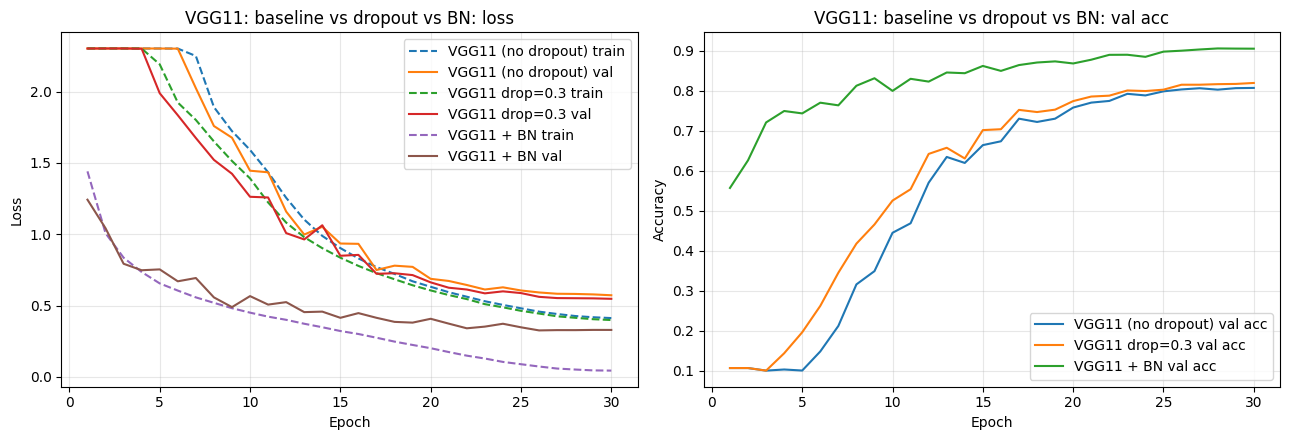

VGG11 + BN: TEST accuracy = 90.17%


0.9017

In [7]:
# ===== CELL 7 — Bonus: VGG + BatchNorm =====
vgg_bn,h_bn = train_model(ModifiedVGG(chosen, dropout=0.0, use_bn=True), f"{chosen} + BN", lr=0.05)
plot_history([h_vgg,h_d3,h_bn], f"{chosen}: baseline vs dropout vs BN")
report_test(vgg_bn,f"{chosen} + BN")